# Examine version 3 of the catalog with amplitudes 

This notebook is used to check whether the amplitude information is correctly added to version 3 of the pick assignment table. 

By Hiroto Bito

In [16]:
import os
import sys
import pandas as pd
import numpy as np

from obspy.core import UTCDateTime
import time
from obspy.core.stream import Stream
import matplotlib.pyplot as plt


parent_dir = '/home/hbito/cascadia_obs_ensemble/utils'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_client import get_waveforms

In [4]:
datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
path_assigned_picks_df = f'{datasets_dir}/Cascadia_updated_catalog_picks_assignment_ver_3_w_amp_test.csv'
assigned_picks_df = pd.read_csv(path_assigned_picks_df, index_col=False)
assigned_picks_df.head(10)

,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation,Amplitude
0,0,2010-01-01T00:15:27.180000Z,UW.PCMD,P,0.049,0,0,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,534.658499
1,1,2010-01-01T00:15:37.840400Z,UW.RVW,P,1.264,0,1,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.149750,-122.742996,504.0,73.403575
2,2,2010-01-01T00:15:33.280000Z,UW.PCMD,S,-0.243,0,2,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,897.182138
3,3,2010-01-01T00:15:42.002000Z,UW.GNW,S,2.402,0,3,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.564130,-122.824980,220.0,2239.571065
4,4,2010-01-01T00:15:43.618400Z,PB.B013,S,-0.651,0,4,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813000,-122.910797,75.3,60.932284
5,5,2010-01-01T00:15:43.768400Z,PB.B943,S,-0.511,0,5,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813202,-122.911301,84.2,45.608438
6,6,2010-01-01T00:15:48.060400Z,UW.BOW,S,-0.263,0,6,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.474831,-123.229301,870.0,26.518675
7,7,2010-01-01T00:17:04.730000Z,UW.PASS,P,-0.499,1,7,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.998299,-122.085197,175.4,240.412236
8,8,2010-01-01T00:17:05.008400Z,PB.B943,P,-0.252,1,8,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,47.813202,-122.911301,84.2,46.170710
9,9,2010-01-01T00:17:05.020400Z,UW.BLN,P,0.415,1,9,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.006624,-122.972646,601.0,94.172872


In [5]:
skipped_csv_path = f'{datasets_dir}/calculate_amplitudes_skipped_picks_test.csv'
skipped_picks_df = pd.read_csv(skipped_csv_path)
skipped_picks_df


,network,station,channel,origin_time,time_pick,starttime,endtime,reason
0,UW,VVHS,*H*,2010-04-16T22:48:21.535000Z,2010-04-16T22:48:24.980000Z,2010-04-16T22:48:24.480000Z,2010-04-16T22:48:26.980000Z,Request failed: No Vertical Component Data Pre...
1,CN,HNB,*H*,2010-04-28T14:36:42.921000Z,2010-04-28T14:36:53.940000Z,2010-04-28T14:36:53.440000Z,2010-04-28T14:36:55.940000Z,Request failed: No Vertical Component Data Pre...
2,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:34.860000Z,2010-04-30T16:01:37.360000Z,Request failed: No Vertical Component Data Pre...
3,UW,SP2,*H*,2010-04-30T20:11:55.912000Z,2010-04-30T20:12:05.360000Z,2010-04-30T20:12:04.860000Z,2010-04-30T20:12:07.360000Z,Request failed: No Vertical Component Data Pre...
4,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:57.350000Z,2010-05-01T04:18:59.850000Z,Request failed: No Vertical Component Data Pre...
...,...,...,...,...,...,...,...,...
36386,BK,JCC,*H*,2015-06-23T09:54:12.649000Z,2015-06-23T09:54:34.378393Z,2015-06-23T09:54:33.878393Z,2015-06-23T09:54:36.378393Z,Request failed: No Vertical Component Data Pre...
36387,BK,JCC,*H*,2015-06-23T13:52:29.836000Z,2015-06-23T13:52:44.418393Z,2015-06-23T13:52:43.918393Z,2015-06-23T13:52:46.418393Z,Request failed: No Vertical Component Data Pre...
36388,BK,JCC,*H*,2015-06-23T13:52:29.836000Z,2015-06-23T13:52:54.938393Z,2015-06-23T13:52:54.438393Z,2015-06-23T13:52:56.938393Z,Request failed: No Vertical Component Data Pre...
36389,BK,JCC,*H*,2015-06-23T22:11:13.828000Z,2015-06-23T22:11:23.638393Z,2015-06-23T22:11:23.138393Z,2015-06-23T22:11:25.638393Z,Request failed: No Vertical Component Data Pre...


test

In [ ]:
path_test = f'{datasets_dir}Cascadia_updated_catalog_picks_assignment_ver_3.csv'
test_df = pd.read_csv(path_test, index_col=False)
print(len(test_df))

1004335


end test

In [6]:
# Print the number of rows of assigned_picks_df and the first 10 rows
print("Number of rows: ", len(assigned_picks_df))
assigned_picks_df.head(10)

Number of rows:  1004335


,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation,Amplitude
0,0,2010-01-01T00:15:27.180000Z,UW.PCMD,P,0.049,0,0,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,534.658499
1,1,2010-01-01T00:15:37.840400Z,UW.RVW,P,1.264,0,1,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.149750,-122.742996,504.0,73.403575
2,2,2010-01-01T00:15:33.280000Z,UW.PCMD,S,-0.243,0,2,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0,897.182138
3,3,2010-01-01T00:15:42.002000Z,UW.GNW,S,2.402,0,3,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.564130,-122.824980,220.0,2239.571065
4,4,2010-01-01T00:15:43.618400Z,PB.B013,S,-0.651,0,4,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813000,-122.910797,75.3,60.932284
5,5,2010-01-01T00:15:43.768400Z,PB.B943,S,-0.511,0,5,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813202,-122.911301,84.2,45.608438
6,6,2010-01-01T00:15:48.060400Z,UW.BOW,S,-0.263,0,6,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.474831,-123.229301,870.0,26.518675
7,7,2010-01-01T00:17:04.730000Z,UW.PASS,P,-0.499,1,7,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.998299,-122.085197,175.4,240.412236
8,8,2010-01-01T00:17:05.008400Z,PB.B943,P,-0.252,1,8,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,47.813202,-122.911301,84.2,46.170710
9,9,2010-01-01T00:17:05.020400Z,UW.BLN,P,0.415,1,9,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.006624,-122.972646,601.0,94.172872


In [7]:
# Print the number of rows of assigned_picks_df and the first 10 rows
print("Number of rows: ", len(skipped_picks_df))
skipped_picks_df.head(10)

Number of rows:  36391


,network,station,channel,origin_time,time_pick,starttime,endtime,reason
0,UW,VVHS,*H*,2010-04-16T22:48:21.535000Z,2010-04-16T22:48:24.980000Z,2010-04-16T22:48:24.480000Z,2010-04-16T22:48:26.980000Z,Request failed: No Vertical Component Data Pre...
1,CN,HNB,*H*,2010-04-28T14:36:42.921000Z,2010-04-28T14:36:53.940000Z,2010-04-28T14:36:53.440000Z,2010-04-28T14:36:55.940000Z,Request failed: No Vertical Component Data Pre...
2,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:34.860000Z,2010-04-30T16:01:37.360000Z,Request failed: No Vertical Component Data Pre...
3,UW,SP2,*H*,2010-04-30T20:11:55.912000Z,2010-04-30T20:12:05.360000Z,2010-04-30T20:12:04.860000Z,2010-04-30T20:12:07.360000Z,Request failed: No Vertical Component Data Pre...
4,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:57.350000Z,2010-05-01T04:18:59.850000Z,Request failed: No Vertical Component Data Pre...
5,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:37.370000Z,2010-06-22T15:49:39.870000Z,Request failed: No Vertical Component Data Pre...
6,UW,SP2,*H*,2010-06-23T01:10:53.872000Z,2010-06-23T01:11:05.360000Z,2010-06-23T01:11:04.860000Z,2010-06-23T01:11:07.360000Z,Request failed: No Vertical Component Data Pre...
7,UW,SP2,*H*,2010-06-24T09:46:51.644000Z,2010-06-24T09:47:05.420000Z,2010-06-24T09:47:04.920000Z,2010-06-24T09:47:07.420000Z,Request failed: No Vertical Component Data Pre...
8,UW,SP2,*H*,2010-06-27T23:17:12.133000Z,2010-06-27T23:17:27.920000Z,2010-06-27T23:17:27.420000Z,2010-06-27T23:17:29.920000Z,Request failed: No Vertical Component Data Pre...
9,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:05:02.260000Z,2010-07-31T04:05:04.760000Z,Request failed: No Vertical Component Data Pre...


### Make plots to make sure that the amplitude calculation was correct

In [8]:
# Function to plot waveforms using Obspy bulk request
 
def plot_waveforms_for_picks(assigned_picks_df, window_before=30, window_after=120, window_amp_calc_before = 0.5, window_amp_calc_after = 2, n_picks=100, source='pnwstore', scaling_factor_vline=0.1):
     
    # Prepare the lists
    bulk = []
    pick_info = []
    # ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))
    ls_idx = np.arange(n_picks)
    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        location = '*'
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = assigned_picks_df.iloc[ls_idx[i]]['time_pick']
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']
        amp = assigned_picks_df.iloc[ls_idx[i]]['Amplitude']

        bulk.append((network, station, location, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'location': location,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase,
            'amp': amp
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']
        amp = pick_info[i]['amp']

        time_pick = pick_info[i]['time_pick']
        time_pick_origin = pick_info[i]['time_pick_origin']

        time.sleep(0.1)

        try:
            st = get_waveforms(
                network=network,
                station=station,
                channel=channel,
                starttime=starttime,
                endtime=endtime,
                source=source
            )
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)

        # ---------------------------------------------------------
        # Select preferred channel family
        # ---------------------------------------------------------

        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        sdata = Stream()

        if has_HH:
            sdata += st.select(id=f'{network}.{station}..HH?')
            channel_prefix = "HH"

        elif has_BH:
            sdata += st.select(id=f'{network}.{station}..BH?')
            channel_prefix = "BH"

        elif has_EH:
            sdata += st.select(id=f'{network}.{station}..EH?')
            channel_prefix = "EH"

        else:
            print(f'No HH, BH, or EH data available at {network}.{station} at {time_pick}. Skipping.')
            continue

        # ---------------------------------------------------------
        # Create figure with 3 components
        # ---------------------------------------------------------

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(12, 8),
            sharex=True
        )

        component_list = ['Z', 'N', 'E']

        for ax, comp in zip(axes, component_list):

            tr_select = sdata.select(channel=f"{channel_prefix}{comp}")

            # -----------------------------------------------------
            # Leave blank if component does not exist
            # -----------------------------------------------------

            if len(tr_select) == 0:

                ax.set_title(f"{channel_prefix}{comp} : No Data")
                ax.grid()

                continue

            tr = tr_select[0].copy()

            # -----------------------------------------------------
            # Process waveform
            # -----------------------------------------------------

            tr.resample(new_sampling_rate)

            tr.detrend(type='demean')
            tr.taper(max_percentage=0.05)
            tr.filter(type='highpass', freq=freq_highpass)

            data = tr.data

            times = np.linspace(
                -window_before,
                window_after,
                tr.stats.npts
            )

            time_vline = time_pick_origin

            ymax = np.max(np.abs(data)) * scaling_factor_vline
            ymin = -np.max(np.abs(data)) * scaling_factor_vline

            xmax = time_vline + window_amp_calc_after
            xmin = time_vline - window_amp_calc_before

            # -----------------------------------------------------
            # Plot waveform
            # -----------------------------------------------------

            ax.axvspan(
                xmin,
                xmax,
                color='b',
                alpha=0.2
            )

            ax.plot(times, data)

            ax.vlines(
                time_vline,
                ymin,
                ymax,
                color='k',
                linestyles='solid'
            )

            ax.hlines(
                amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.hlines(
                -amp,
                xmax=xmax,
                xmin=xmin,
                color='r'
            )

            ax.set_ylabel(comp)
            ax.grid()

        # ---------------------------------------------------------
        # Common formatting
        # ---------------------------------------------------------

        axes[0].set_title(
            f"Origin ID: {info['orid']} | "
            f"Pick ID: {info['pick_id']} | "
            f"Network: {info['network']} | "
            f"Station: {info['station']} | "
            f"Phase: {info['phase']}"
        )

        axes[-1].set_xlabel("Time (s) from Origin Time")

        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        axes[-1].set_xticks(ticks=ticks, labels=str_ticks)

        # Event information box
        info_text = (
            f"Origin Time: {info['origin_time']}\n"
            f"Latitude: {info['latitude']}\n"
            f"Longitude: {info['longitude']}\n"
            f"Depth: {info['depth']}"
        )

        props = dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )

        axes[0].text(
            0.98,
            0.98,
            info_text,
            transform=axes[0].transAxes,
            fontsize=10,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=props
        )

        plt.tight_layout()
        plt.show()
        plt.close(fig)

        time.sleep(0.1)

In [12]:
# Define the variables in the function
idx = np.random.choice(a=len(assigned_picks_df), size=20)
df = assigned_picks_df.iloc[idx]
window_before = 30 # in sec
window_after = 150 # in sec
window_amp_calc_before = 0.5 # in sec
window_amp_calc_after = 2 # in sec
n_picks = 20
source = 'pnwstore'
scaling_factor_vline = 0.3

In [13]:
df

,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation,Amplitude
999444,999444,2015-06-16T20:55:32.468400Z,PB.B047,S,-1.012,63589,999444,40.87421,-124.35574,24.5445,0.970,2015-06-16 20:55:10.891000+00:00,0.904,22,33,55,40.249933,-124.169848,80.0,97.565760
426333,426333,2012-10-26T23:54:36.058400Z,PB.B203,P,0.069,28067,426333,46.10879,-122.68507,20.8795,0.650,2012-10-26 23:54:30.193000+00:00,0.146,5,7,12,46.168999,-122.333664,814.4,14.123506
895490,895490,2015-01-30T16:55:43.793439Z,Z5.GB101,P,0.854,57460,895490,40.39697,-124.31753,20.9955,0.908,2015-01-30 16:55:10.468000+00:00,1.312,41,45,86,42.020500,-126.587997,-3585.0,19917.078412
156937,156937,2011-04-24T11:51:42.478400Z,PB.B943,S,0.057,11100,156937,47.40270,-122.70301,21.6385,0.691,2011-04-24 11:51:27.555000+00:00,0.377,7,11,18,47.813202,-122.911301,84.2,46.330420
127198,127198,2011-01-28T05:42:59.730300Z,UW.EDM,S,0.083,8977,127198,46.28870,-122.20798,6.2975,0.947,2011-01-28 05:42:55.841000+00:00,0.673,21,22,43,46.197170,-122.151210,1611.0,2761.067957
684771,684771,2014-03-27T07:56:08.920000Z,NC.KMPB,S,-0.079,44576,684771,40.57891,-123.75491,22.7920,0.670,2014-03-27 07:55:55.187000+00:00,0.265,4,5,9,40.417194,-124.120758,938.0,468.375353
9333,9333,2010-01-18T10:36:20.018400Z,PB.B932,S,0.019,735,9333,40.34330,-124.79714,1.8805,0.622,2010-01-18 10:36:03.883000+00:00,0.320,5,5,10,40.275002,-124.221199,52.0,99.142837
476521,476521,2013-01-02T11:50:18.518400Z,PB.B049,P,0.086,30741,476521,40.33255,-124.04897,24.4375,0.786,2013-01-02 11:50:12.526000+00:00,1.027,15,21,36,40.237499,-123.819702,117.0,129.266261
193893,193893,2011-08-15T19:15:11.189900Z,UW.MTM,S,0.236,13731,193893,45.33742,-122.05247,21.2275,0.625,2011-08-15 19:14:48.359000+00:00,0.280,11,9,20,46.025330,-122.212870,1121.0,160.720160
167625,167625,2011-05-26T16:35:40.018400Z,PB.B045,P,0.344,11858,167625,40.37475,-125.59407,18.0730,0.755,2011-05-26 16:35:19.904000+00:00,0.494,10,6,16,40.436001,-123.996498,29.4,283.325425


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


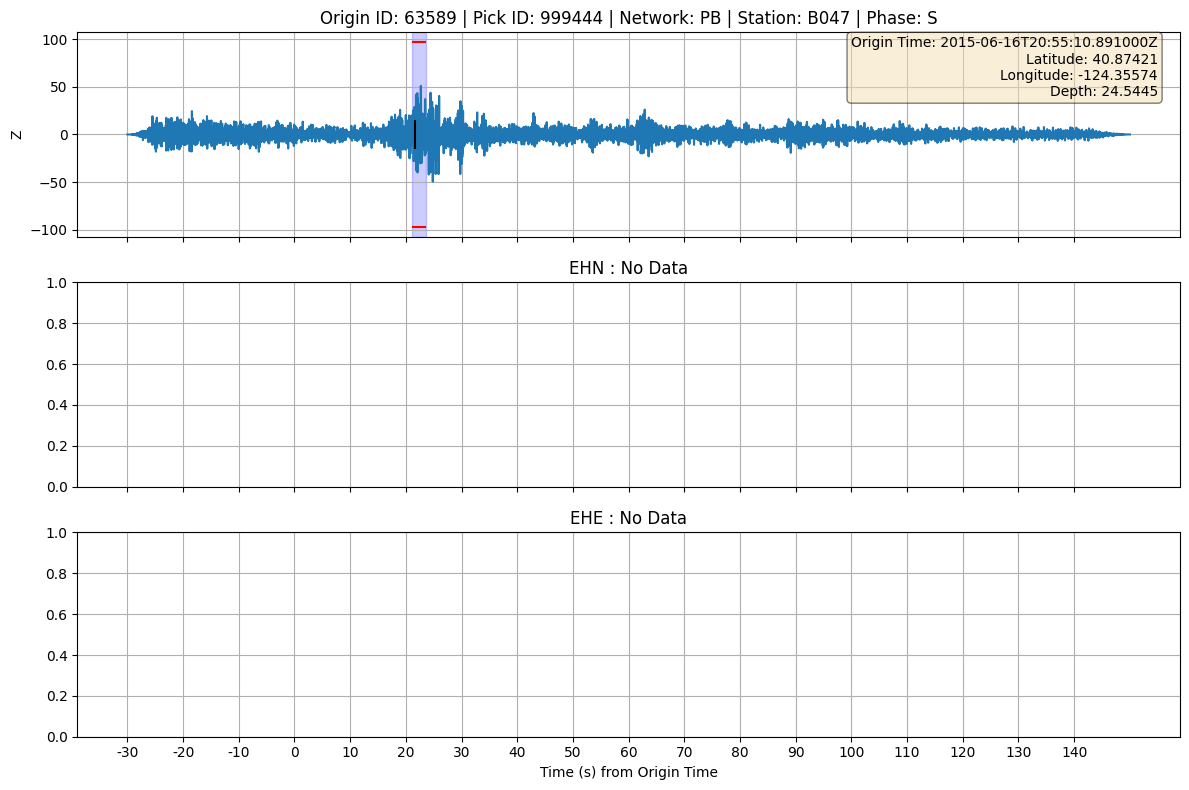

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


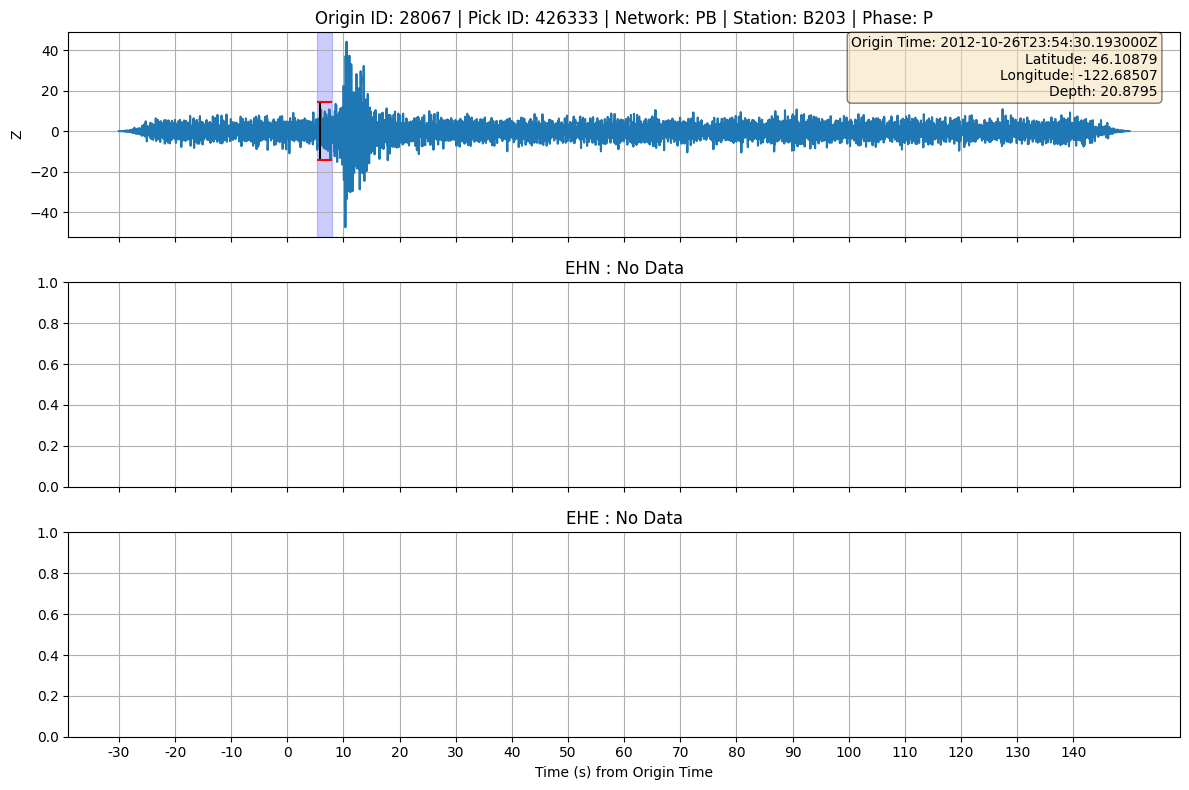

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


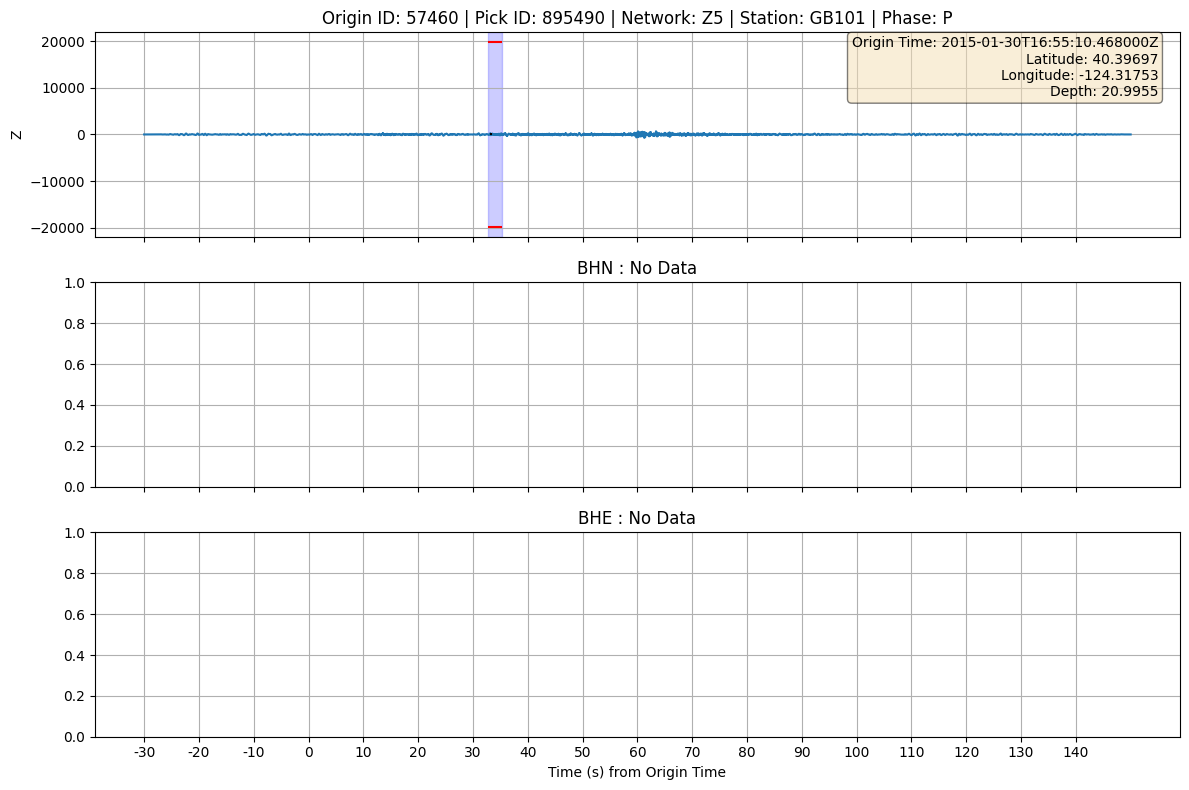

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


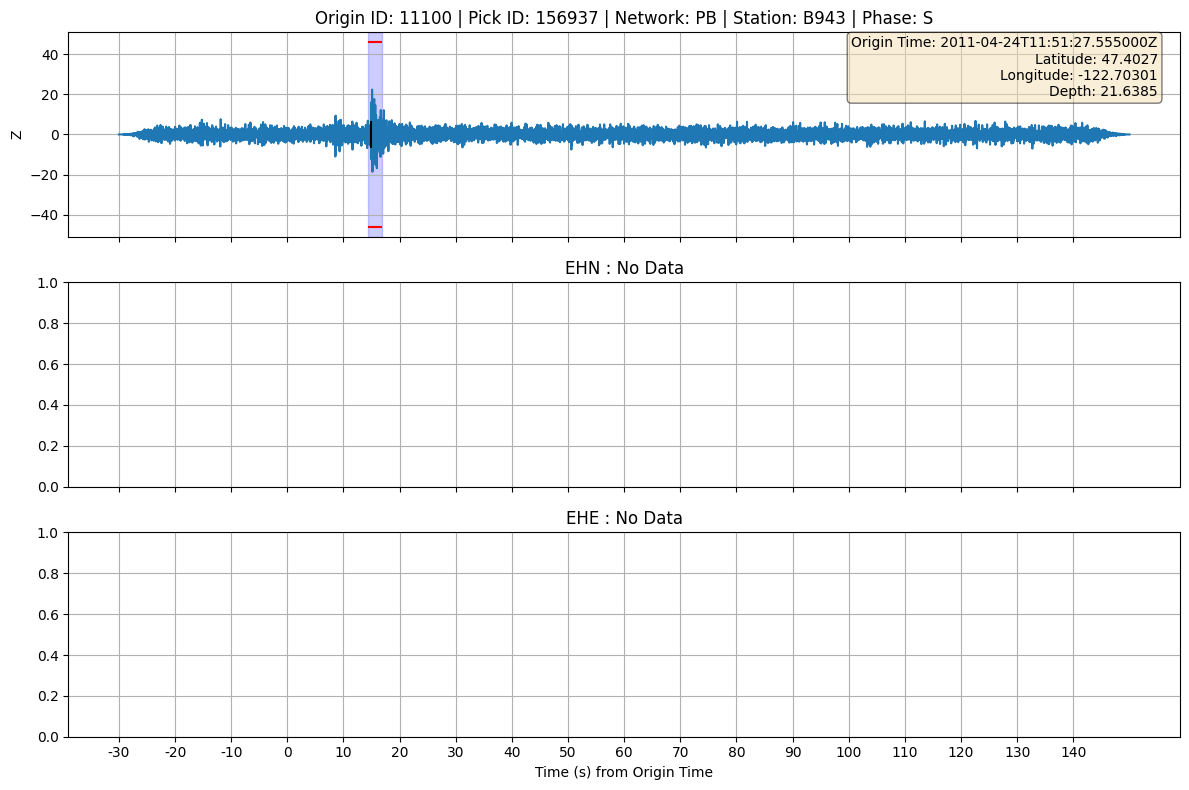

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


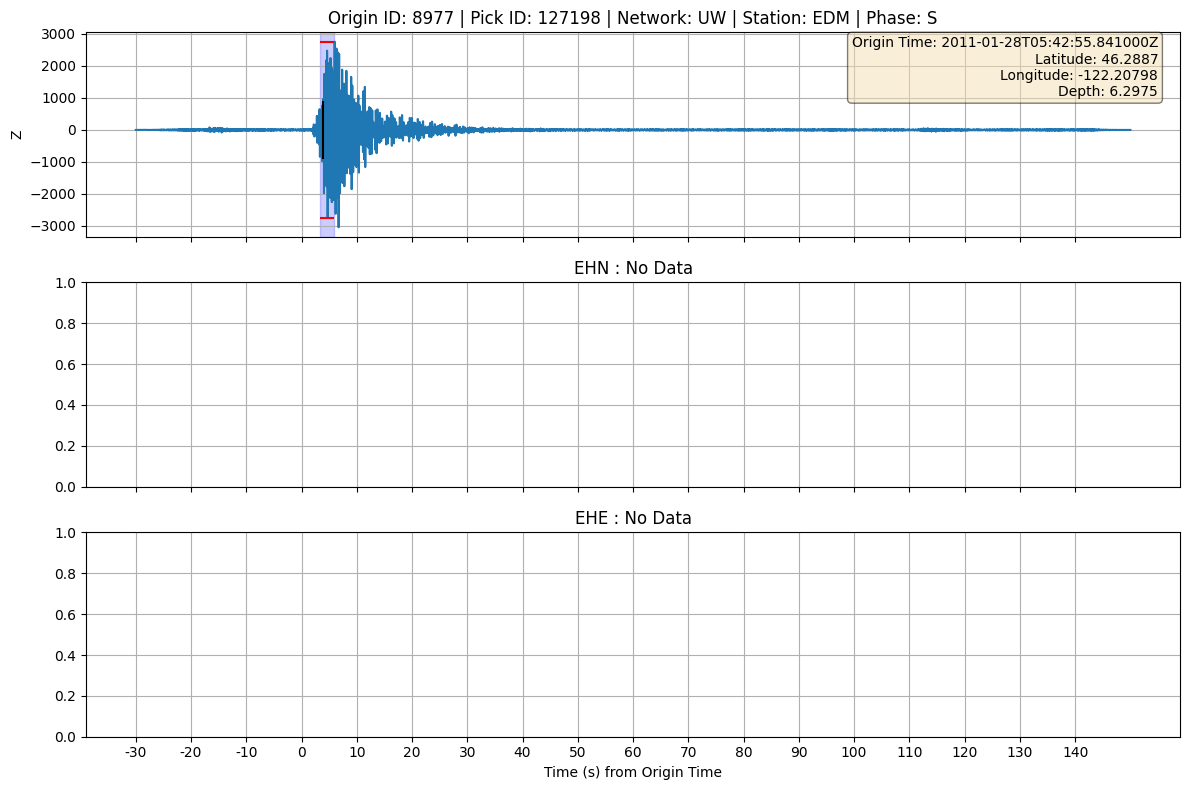

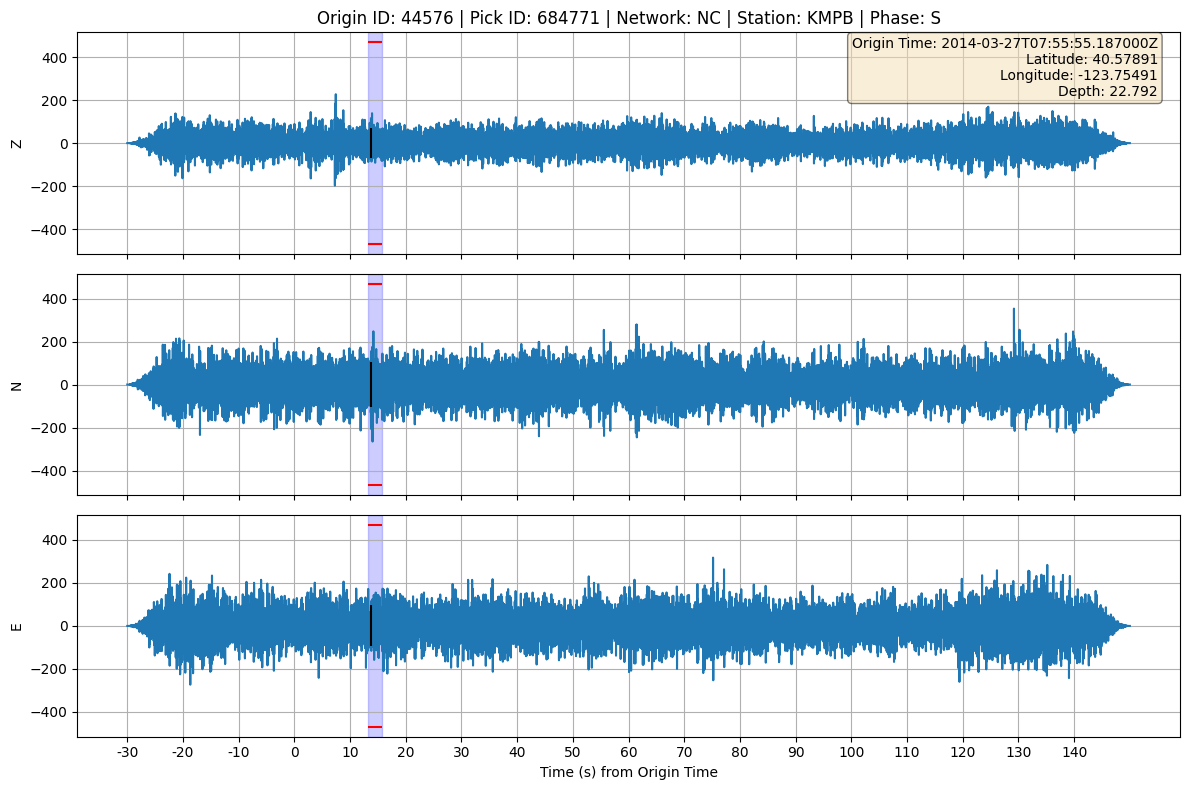

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


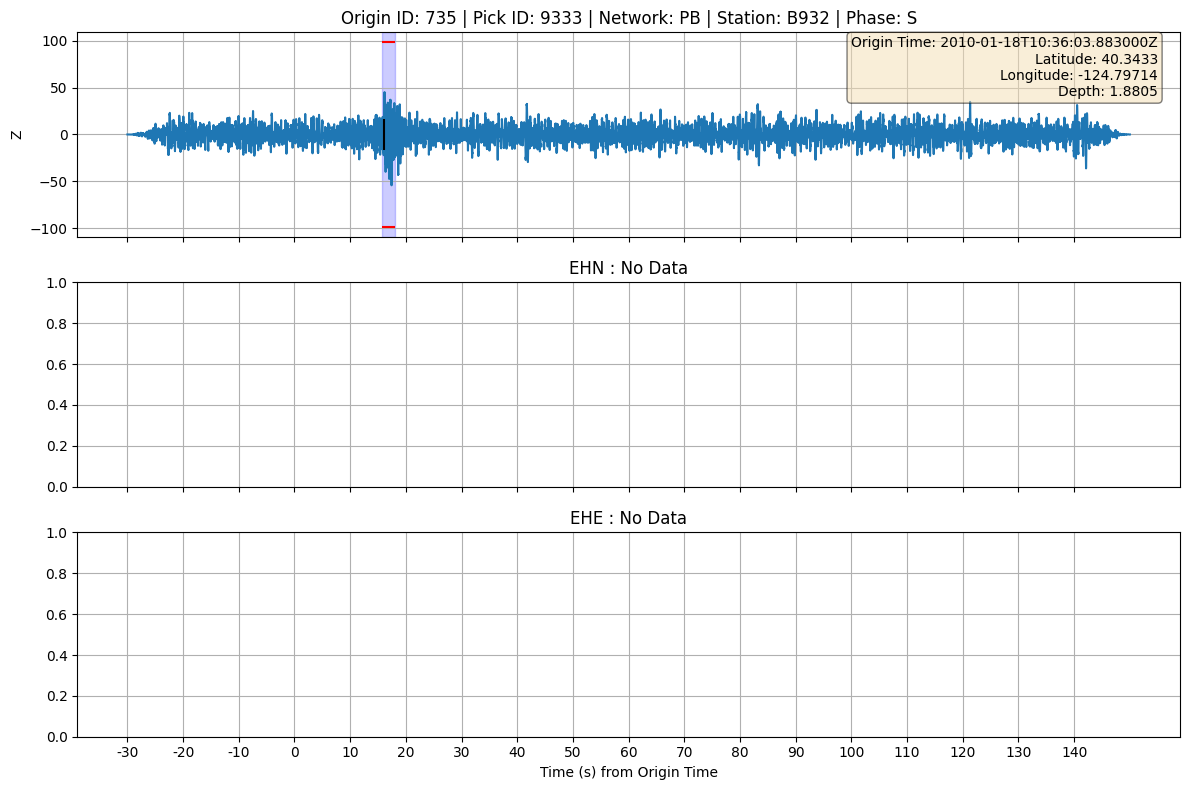

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


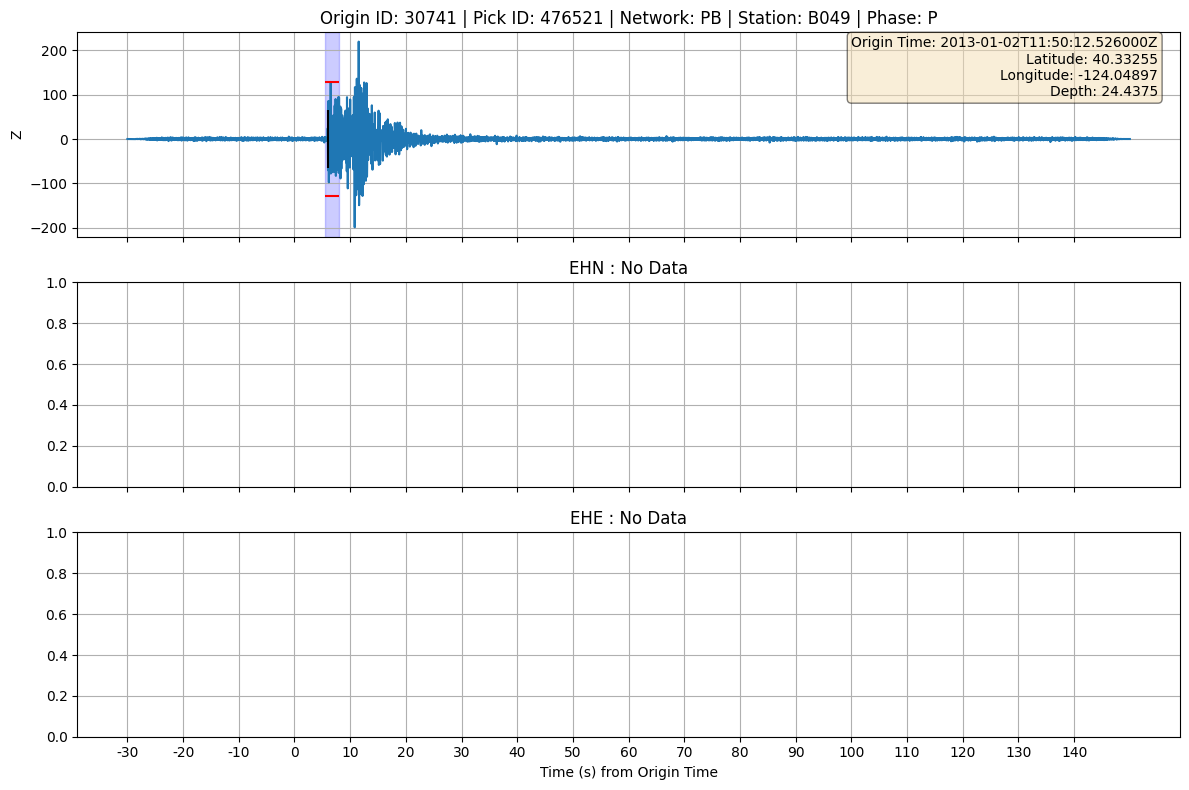

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


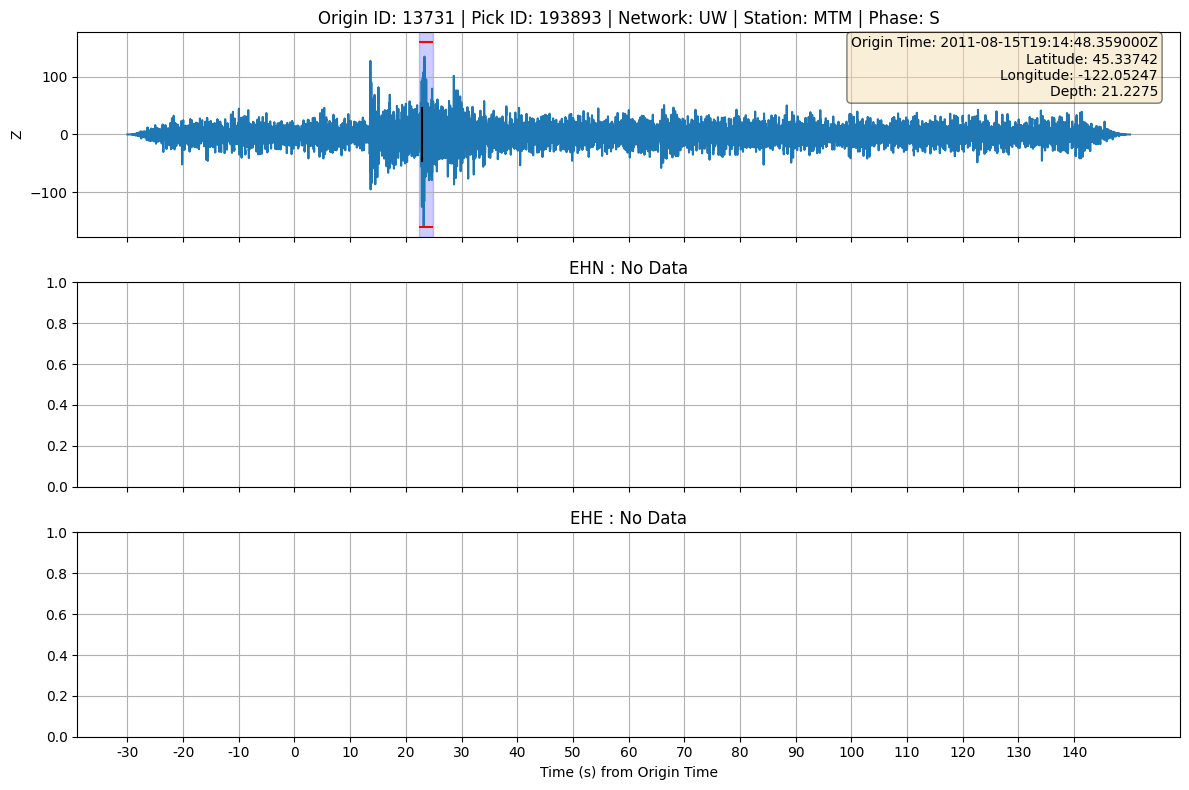

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


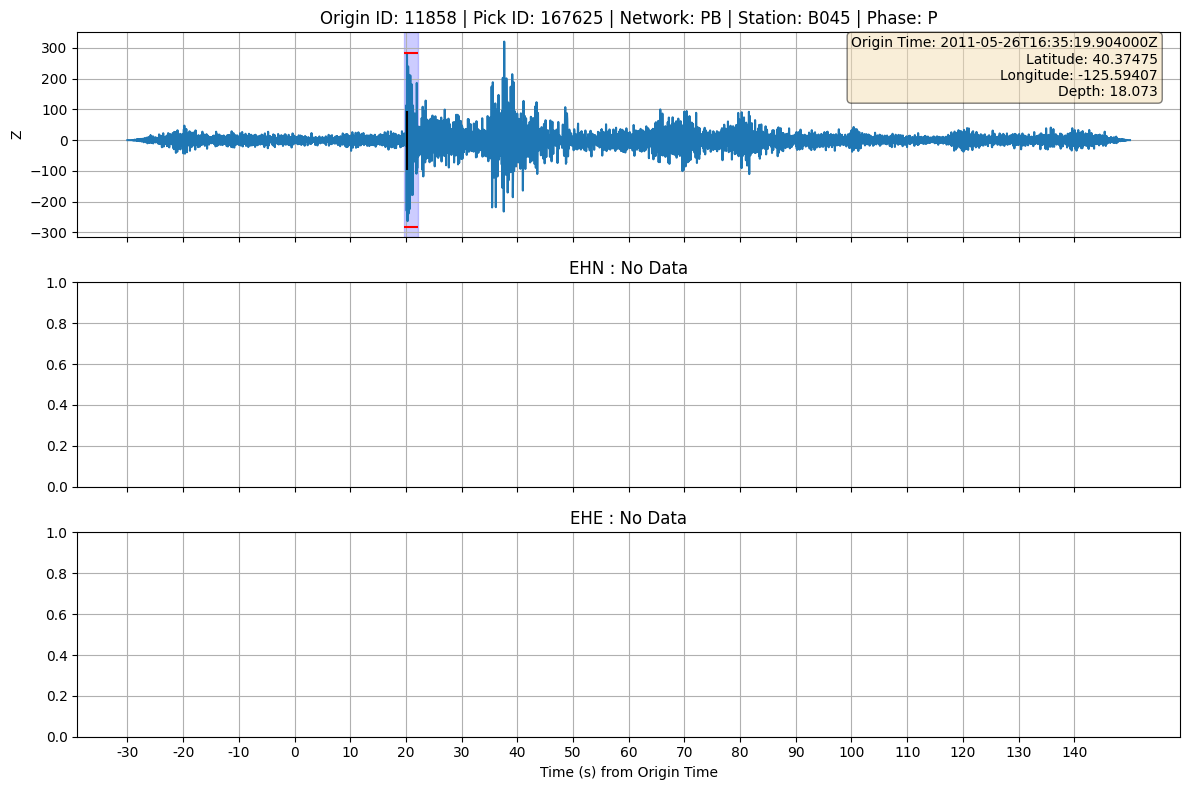

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


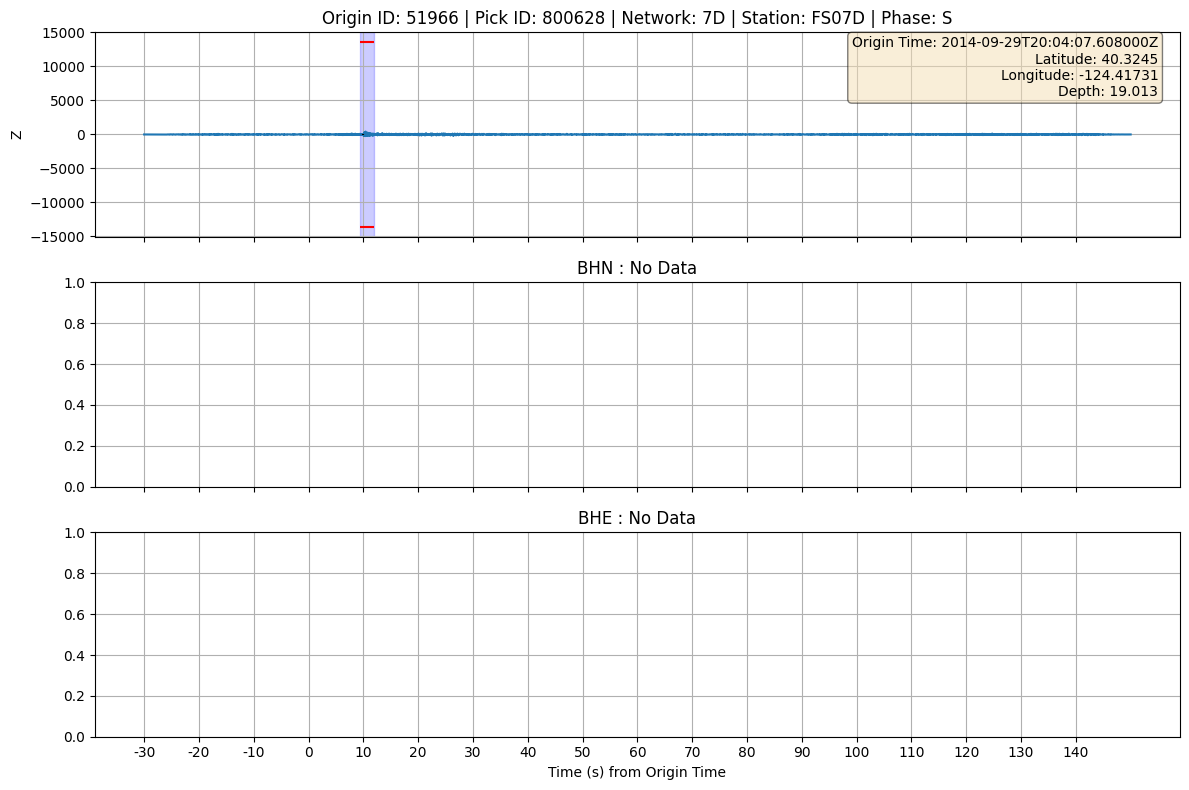

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


No HH, BH, or EH data available at NC.KSM at 2014-08-05T20:45:53.647700Z. Skipping.


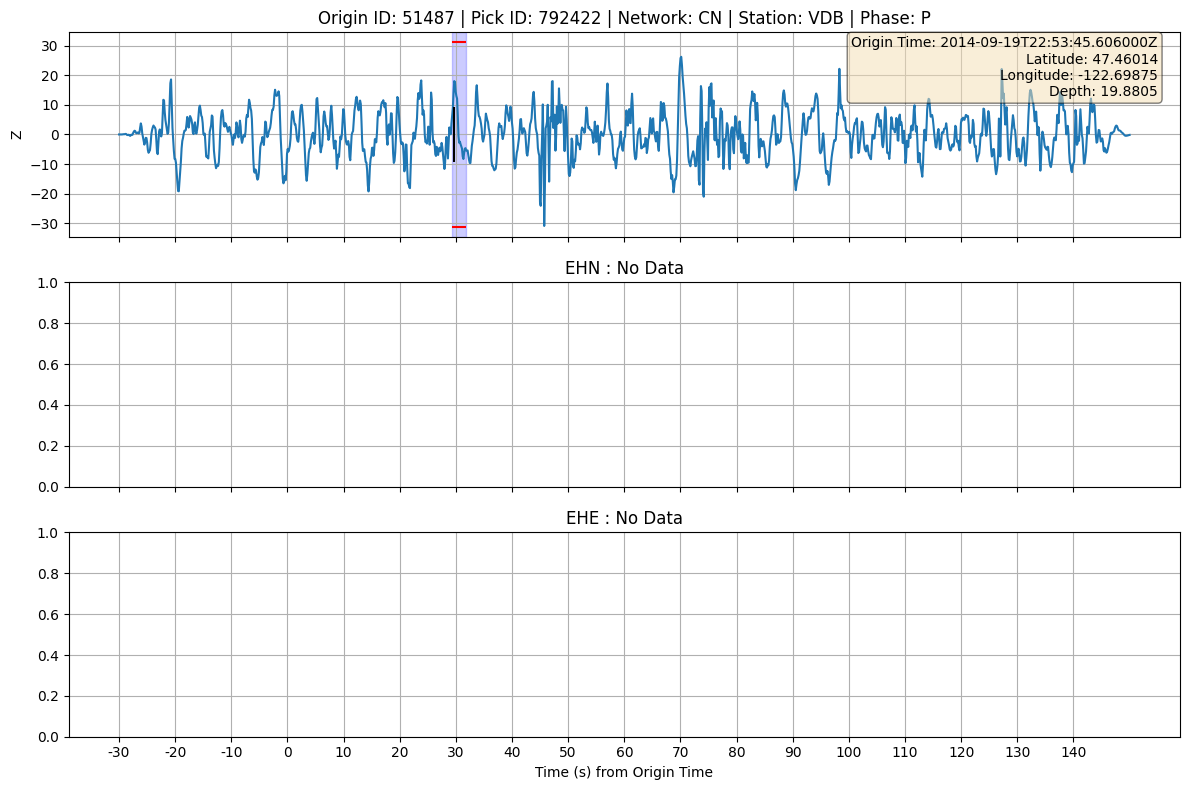

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


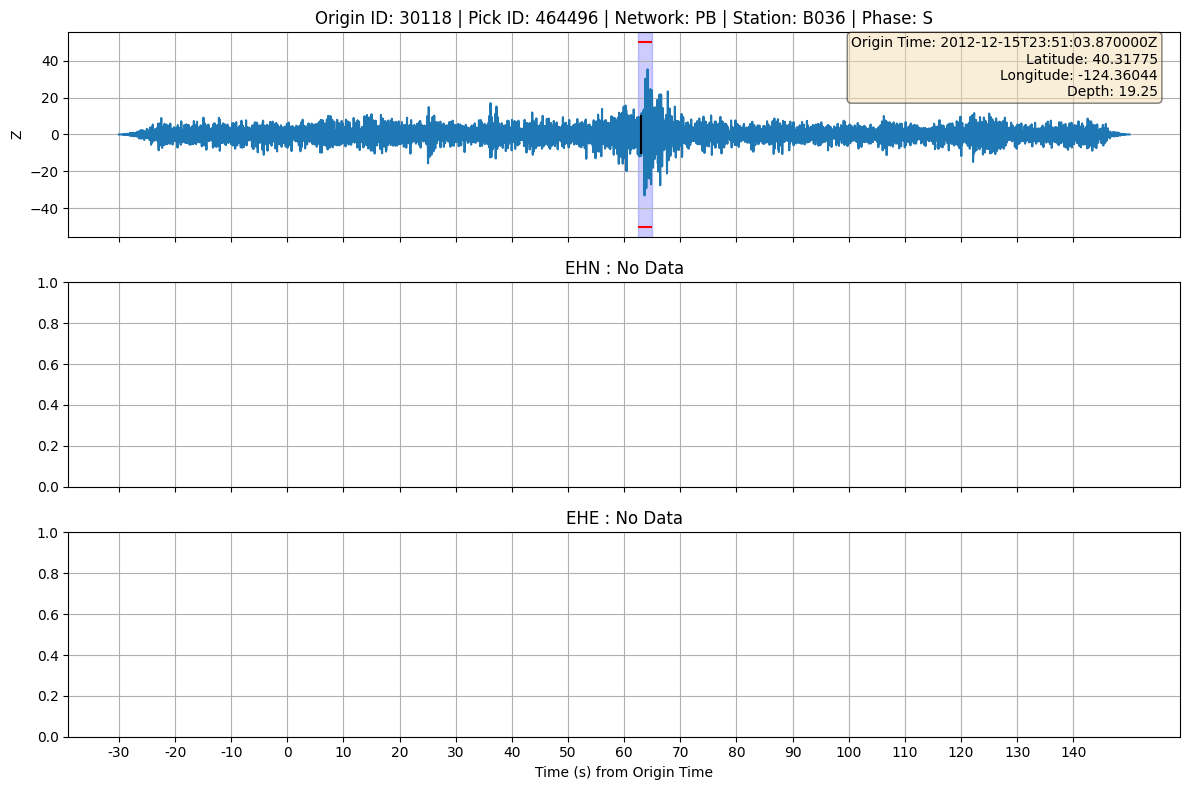

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


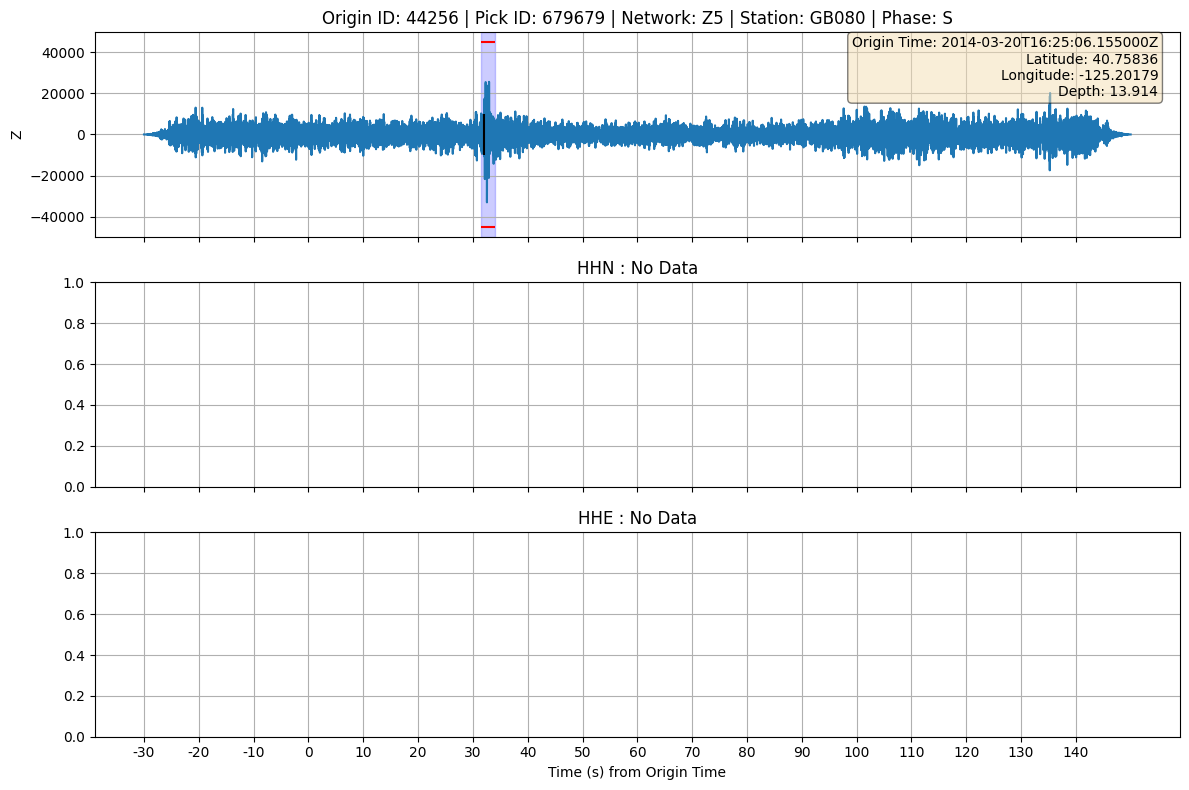

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


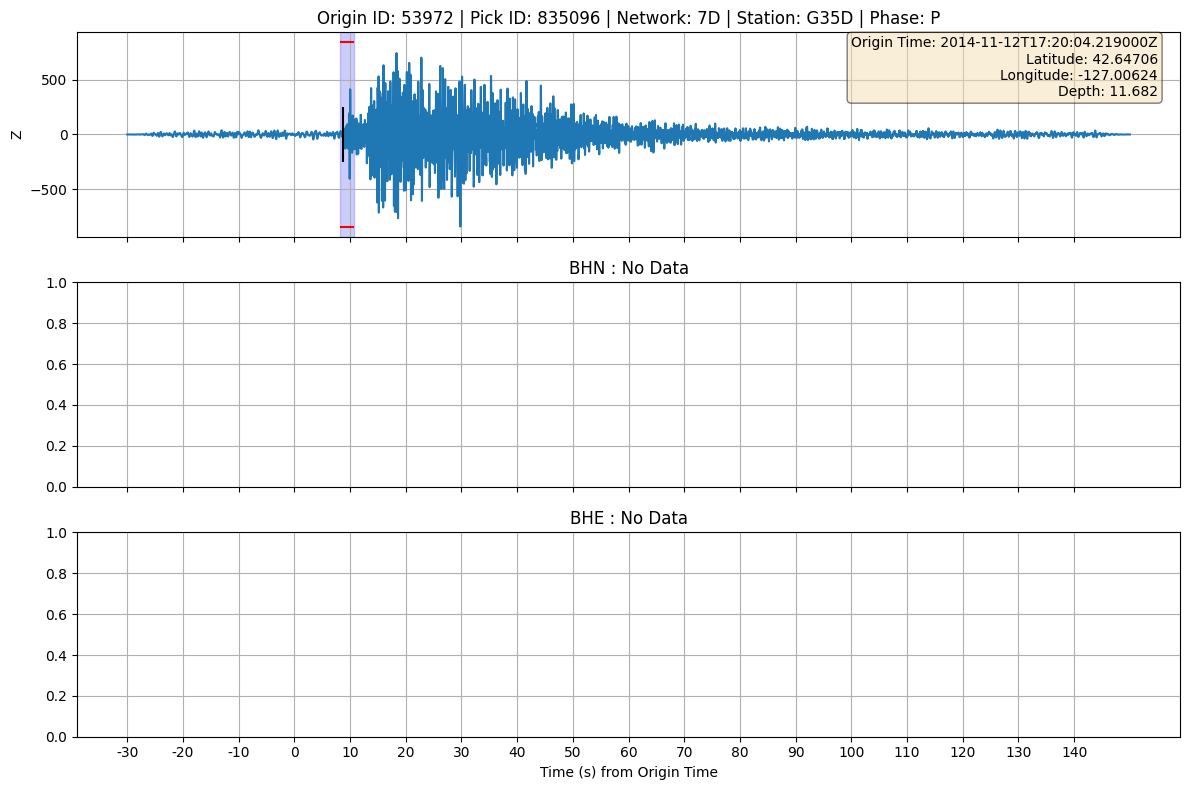

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


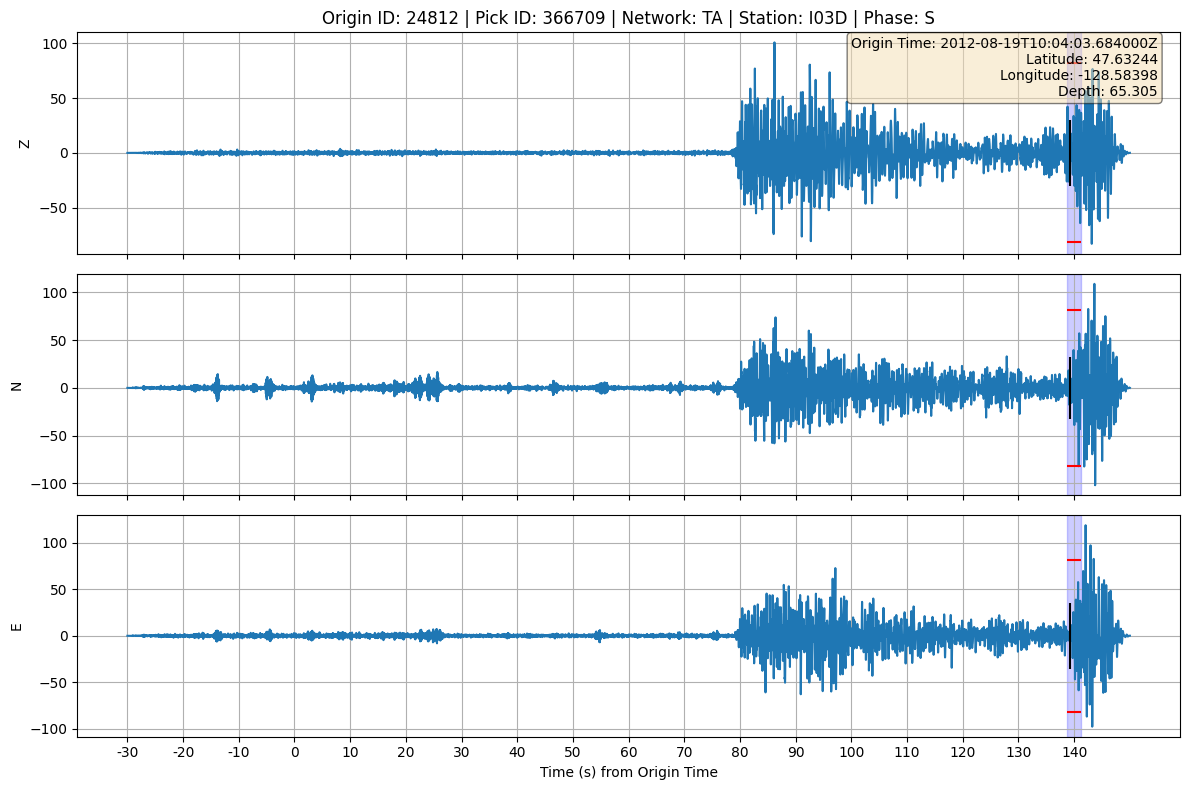

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


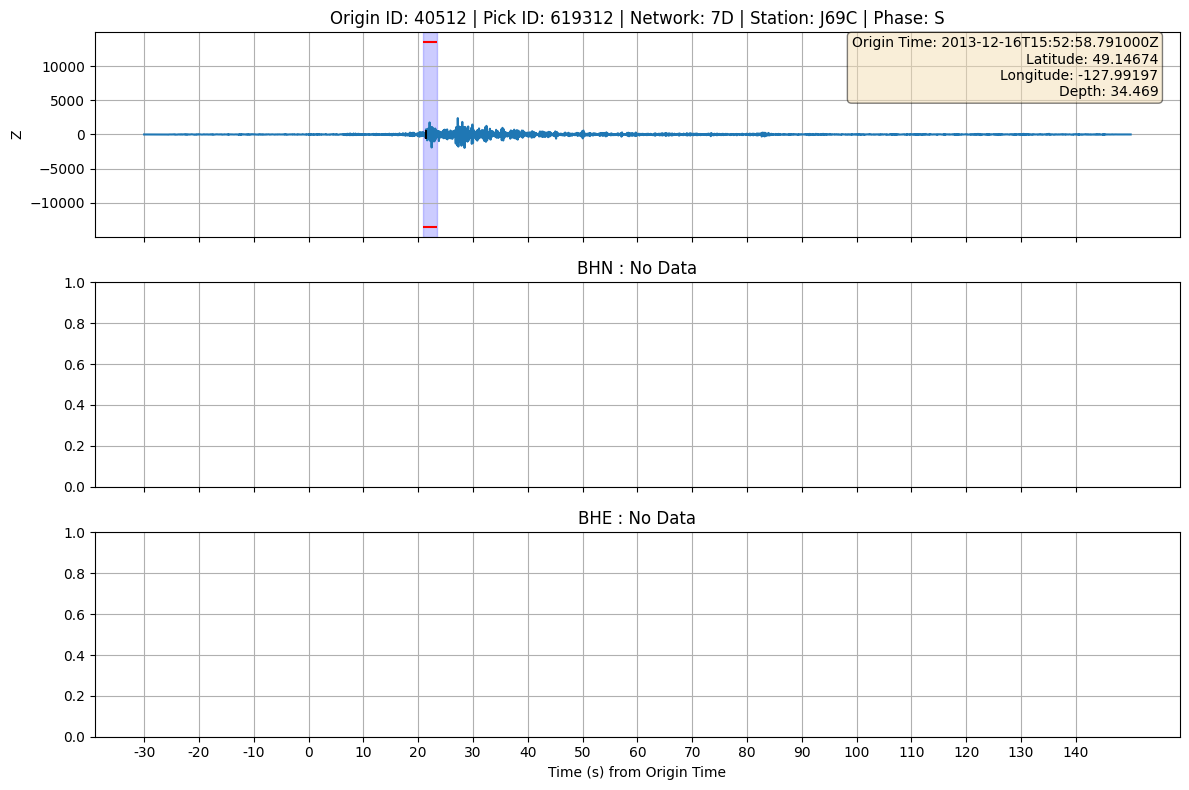

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


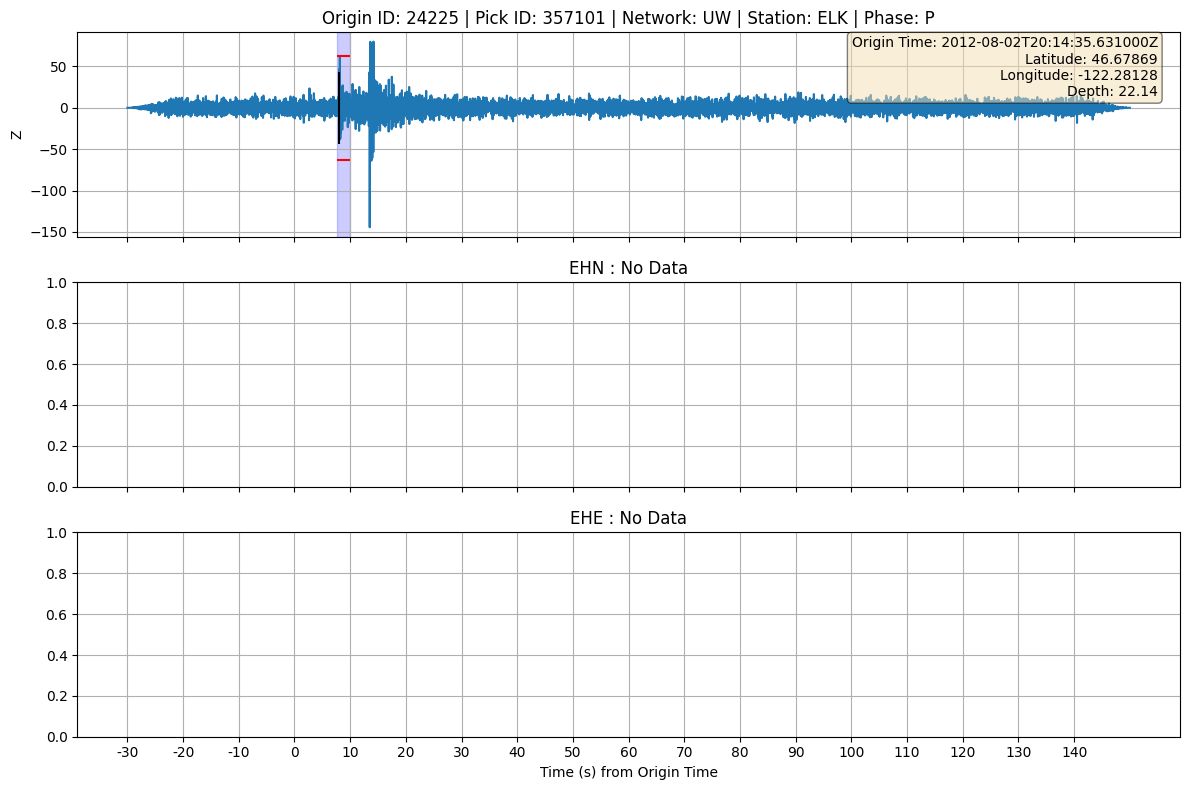

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


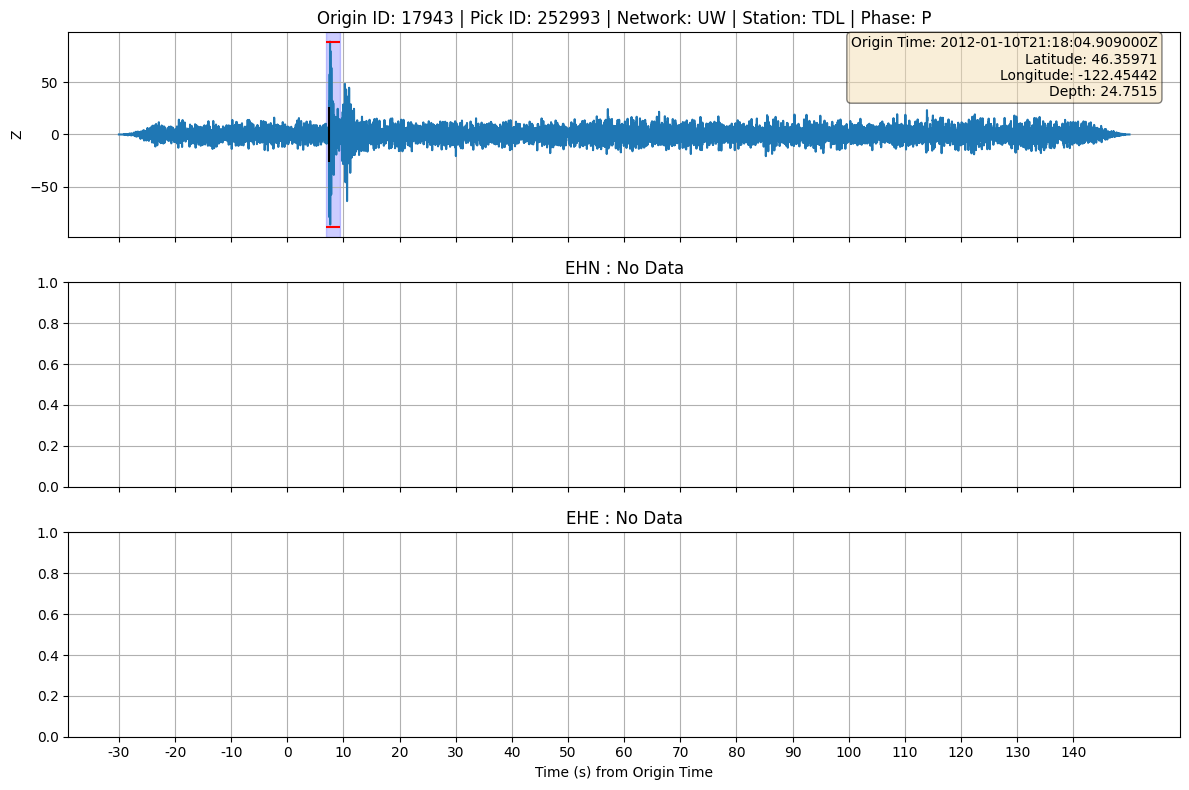

In [17]:
plot_waveforms_for_picks(df, window_before, window_after, window_amp_calc_before, window_amp_calc_after, n_picks, source, scaling_factor_vline)